In [1]:
import torch
from torch import nn

def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    if not torch.is_grad_enabled():
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        X_hat = (X - mean) / torch.sqrt(var + eps)
        moving_mean = momentum * moving_mean + (1.0 - momentum) * mean
        moving_var = momentum * moving_var + (1.0 - momentum) * var
    Y = gamma * X_hat + beta
    return Y, moving_mean.data, moving_var.data

In [2]:
class BatchNorm(nn.Module):
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.9)
        return Y

In [3]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), BatchNorm(6, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), BatchNorm(16, num_dims=4), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16 * 4 * 4, 120), BatchNorm(120, num_dims=2), nn.Sigmoid(),
    nn.Linear(120, 84), BatchNorm(84, num_dims=2), nn.Sigmoid(),
    nn.Linear(84, 10))

In [6]:
# D2L 训练代码依赖的本地等价实现
import time
import matplotlib.pyplot as plt
from IPython import display
import torchvision
from torch.utils import data
from torchvision import transforms

def try_gpu(i=0):
    """存在第 i 块 GPU 时返回该设备，否则返回 CPU。"""
    if torch.cuda.device_count() >= i + 1:
        return torch.device(f'cuda:{i}')
    return torch.device('cpu')

def accuracy(y_hat, y):
    """返回一个批次中预测正确的样本数。"""
    if y_hat.ndim > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(dim=1)
    return float((y_hat.to(y.dtype) == y).sum())

class Accumulator:
    """在多个批次之间累加若干数值。"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

class Timer:
    """记录多段代码的运行时间。"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        self.tik = time.perf_counter()

    def stop(self):
        self.times.append(time.perf_counter() - self.tik)
        return self.times[-1]

    def sum(self):
        return sum(self.times)

class Animator:
    """在 notebook 中逐步绘制训练曲线。"""
    def __init__(self, xlabel=None, ylabel=None, legend=None,
                 xlim=None, ylim=None, fmts=('-', 'm--', 'g-.'),
                 figsize=(3.5, 2.5)):
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.legend = [] if legend is None else legend
        self.xlim = xlim
        self.ylim = ylim
        self.fmts = fmts
        self.X, self.Y = None, None
        self.fig, self.ax = plt.subplots(figsize=figsize)

    def add(self, x, y):
        if not isinstance(y, (list, tuple)):
            y = [y]
        if not isinstance(x, (list, tuple)):
            x = [x] * len(y)
        if self.X is None:
            self.X = [[] for _ in range(len(y))]
            self.Y = [[] for _ in range(len(y))]
        for x_value, y_value, x_values, y_values in zip(x, y, self.X, self.Y):
            if x_value is not None and y_value is not None:
                x_values.append(x_value)
                y_values.append(y_value)
        self.ax.clear()
        for x_values, y_values, fmt in zip(self.X, self.Y, self.fmts):
            self.ax.plot(x_values, y_values, fmt)
        self.ax.set_xlabel(self.xlabel)
        self.ax.set_ylabel(self.ylabel)
        if self.xlim is not None:
            self.ax.set_xlim(self.xlim)
        if self.ylim is not None:
            self.ax.set_ylim(self.ylim)
        if self.legend:
            self.ax.legend(self.legend)
        self.ax.grid(True)
        display.display(self.fig)
        display.clear_output(wait=True)

def get_dataloader_workers():
    return 4

def load_data_fashion_mnist(batch_size, resize = None):
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root = "../data", train = True, transform = trans, download = True
    )   
    mnist_test = torchvision.datasets.FashionMNIST(
        root = "../data", train = False, transform = trans, download = True
    )
    return(data.DataLoader(mnist_train, batch_size, shuffle = True, num_workers = get_dataloader_workers(), pin_memory=True),
           data.DataLoader(mnist_test, batch_size, shuffle = False, num_workers = get_dataloader_workers(), pin_memory=True))

def evaluate_accuracy_gpu(net, data_iter, device=None):
    """Compute the accuracy for a model on a dataset using a GPU"""
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # Required for BERT fine-tuning (to be covered later)
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """Train a model with a GPU (defined in Chapter 6)."""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'train loss {train_l:.3f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on {str(device)}')

train loss 0.260, train acc 0.904, test acc 0.851
82443.8 examples/sec on cuda:0


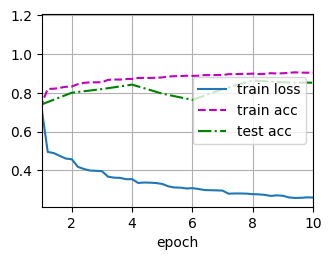

In [7]:
lr, num_epochs, batch_size = 1.0, 10, 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())

In [8]:
net = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5), nn.BatchNorm2d(6), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(6, 16, kernel_size=5), nn.BatchNorm2d(16), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2), nn.Flatten(),
    nn.Linear(16 * 4 * 4, 120), nn.BatchNorm1d(120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.BatchNorm1d(84), nn.Sigmoid(),
    nn.Linear(84, 10))

train loss 0.264, train acc 0.902, test acc 0.847
139014.3 examples/sec on cuda:0


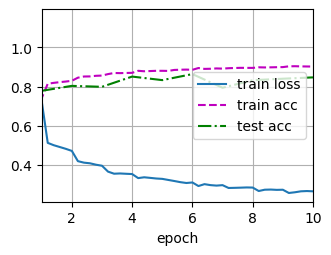

In [9]:
train_ch6(net, train_iter, test_iter, num_epochs, lr, try_gpu())